In [1]:
import pandas as pd
import os

# --- Configuration ---
BASE_RESULTS_PATH = '/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/tomtomresult'
OUTPUT_FILE = 'corrected_tomtom_summary.tsv'

COLUMN_NAMES = [
    'Query_ID', 'Target_ID', 'Optimal_offset', 'p-value', 'E-value',
    'q-value', 'Overlap', 'Query_consensus', 'Target_consensus', 'Orientation'
]

all_best_matches = []

print("Starting to process TOMTOM result files...")
filter_id_list = list()

for i in range(512):
    filter_dir = f'filter{i}'
    tomtom_file_path = os.path.join(BASE_RESULTS_PATH, filter_dir, 'tomtom.tsv')

    if not os.path.exists(tomtom_file_path):
        continue

    try:
        tomtom_df = pd.read_csv(tomtom_file_path, sep='\t', comment='#')
        if not tomtom_df.empty:
            best_match = tomtom_df.iloc[0]
            all_best_matches.append(best_match)
            filter_id_list.append(i)
    except pd.errors.EmptyDataError:
        continue
    except Exception as e:
        print(f"Error processing file for {filter_dir}: {e}")

print(f"\nSuccessfully processed and found matches in {len(all_best_matches)} files.")

if all_best_matches:
    # Concatenate all the series into a single DataFrame.
    final_summary_df = pd.DataFrame(all_best_matches)
    final_summary_df = final_summary_df.reset_index(drop=True)
    final_summary_df.columns = COLUMN_NAMES

    
    # Create the 'TF_Family' column from the 'Target_ID' column.
    print("Creating 'TF_Family' column...")
    final_summary_df['TF_Family'] = final_summary_df['Target_ID'].str.split('_').str[0]

    final_summary_df['Filter_ID'] = filter_id_list
    # Save the final DataFrame to a new tab-separated file.
    final_summary_df.to_csv(OUTPUT_FILE, sep='\t', index=False)
    
    print(f"\nCorrected summary file has been created: '{OUTPUT_FILE}'")
    print("Here is a preview of the first 5 rows (with correct index):")
    print(final_summary_df.head())
else:
    print("No data was collected. The output file was not created.")

Starting to process TOMTOM result files...

Successfully processed and found matches in 507 files.
Creating 'TF_Family' column...

Corrected summary file has been created: 'corrected_tomtom_summary.tsv'
Here is a preview of the first 5 rows (with correct index):
        Query_ID                             Target_ID  Optimal_offset  \
0  1-WGAGRWNNNNN     MYBrelated_tnt.At1g49010_col_a_m1               5   
1  1-NTCGTYDNHNN             MYB_tnt.MYB56_colamp_a_m1               4   
2  1-WVAGRTNNNNN  MYBrelated_tnt.AT5G56840_colamp_a_m1               6   
3   1-NNDNATCVAW           ARID_tnt.AT2G17410_col_a_m1               4   
4  1-STCWTWNNNHN             C2H2_tnt.SGR5_colamp_a_m1               4   

    p-value   E-value   q-value  Overlap Query_consensus  Target_consensus  \
0  0.000768  0.669840  1.000000       10     AGAGGAAAAAA   GAGGATAAGGTTAAT   
1  0.000719  0.626941  0.614756       11     ATCGTTTATTT   AAATACCGTTATTTA   
2  0.000073  0.063347  0.119987       10     TGAGGTTAAAA  

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")


file_path = '/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/corrected_tomtom_summary.tsv'
summary_df = pd.read_csv(file_path, sep='\t')

print(summary_df.head())

        Query_ID                             Target_ID  Optimal_offset  \
0  1-WGAGRWNNNNN     MYBrelated_tnt.At1g49010_col_a_m1               5   
1  1-NTCGTYDNHNN             MYB_tnt.MYB56_colamp_a_m1               4   
2  1-WVAGRTNNNNN  MYBrelated_tnt.AT5G56840_colamp_a_m1               6   
3   1-NNDNATCVAW           ARID_tnt.AT2G17410_col_a_m1               4   
4  1-STCWTWNNNHN             C2H2_tnt.SGR5_colamp_a_m1               4   

    p-value   E-value   q-value  Overlap Query_consensus  Target_consensus  \
0  0.000768  0.669840  1.000000       10     AGAGGAAAAAA   GAGGATAAGGTTAAT   
1  0.000719  0.626941  0.614756       11     ATCGTTTATTT   AAATACCGTTATTTA   
2  0.000073  0.063347  0.119987       10     TGAGGTTAAAA  TATGGATAAGGTTATA   
3  0.001591  1.387610  0.575376       10      AAAAATCGAA   AAATTAAAATTAAAT   
4  0.000020  0.017551  0.034067       11     CTCTTTTTTTT   TTTTGTCTTTTTTTT   

  Orientation   TF_Family  
0           -  MYBrelated  
1           -         MYB  
2 

--- Diagnostics ---
Loaded DataFrame shape (rows, columns): (507, 11)
First 5 rows of the DataFrame:
        Query_ID                             Target_ID  Optimal_offset  \
0  1-WGAGRWNNNNN     MYBrelated_tnt.At1g49010_col_a_m1               5   
1  1-NTCGTYDNHNN             MYB_tnt.MYB56_colamp_a_m1               4   
2  1-WVAGRTNNNNN  MYBrelated_tnt.AT5G56840_colamp_a_m1               6   
3   1-NNDNATCVAW           ARID_tnt.AT2G17410_col_a_m1               4   
4  1-STCWTWNNNHN             C2H2_tnt.SGR5_colamp_a_m1               4   

    p-value   E-value   q-value  Overlap Query_consensus  Target_consensus  \
0  0.000768  0.669840  1.000000       10     AGAGGAAAAAA   GAGGATAAGGTTAAT   
1  0.000719  0.626941  0.614756       11     ATCGTTTATTT   AAATACCGTTATTTA   
2  0.000073  0.063347  0.119987       10     TGAGGTTAAAA  TATGGATAAGGTTATA   
3  0.001591  1.387610  0.575376       10      AAAAATCGAA   AAATTAAAATTAAAT   
4  0.000020  0.017551  0.034067       11     CTCTTTTTTTT   TTTTG

/tmp/ipykernel_1930423/2947685937.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1930423/2947685937.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=(data_plot_pct.values * 100), y=data_plot_pct.index, palette="magma")



Loaded MEME database: 54 TF families detected.


/tmp/ipykernel_1930423/2947685937.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=data_plot_abs.values, y=data_plot_abs.index, palette="viridis")



Saved figure: TF_Family_2_Panel_Comparison.png


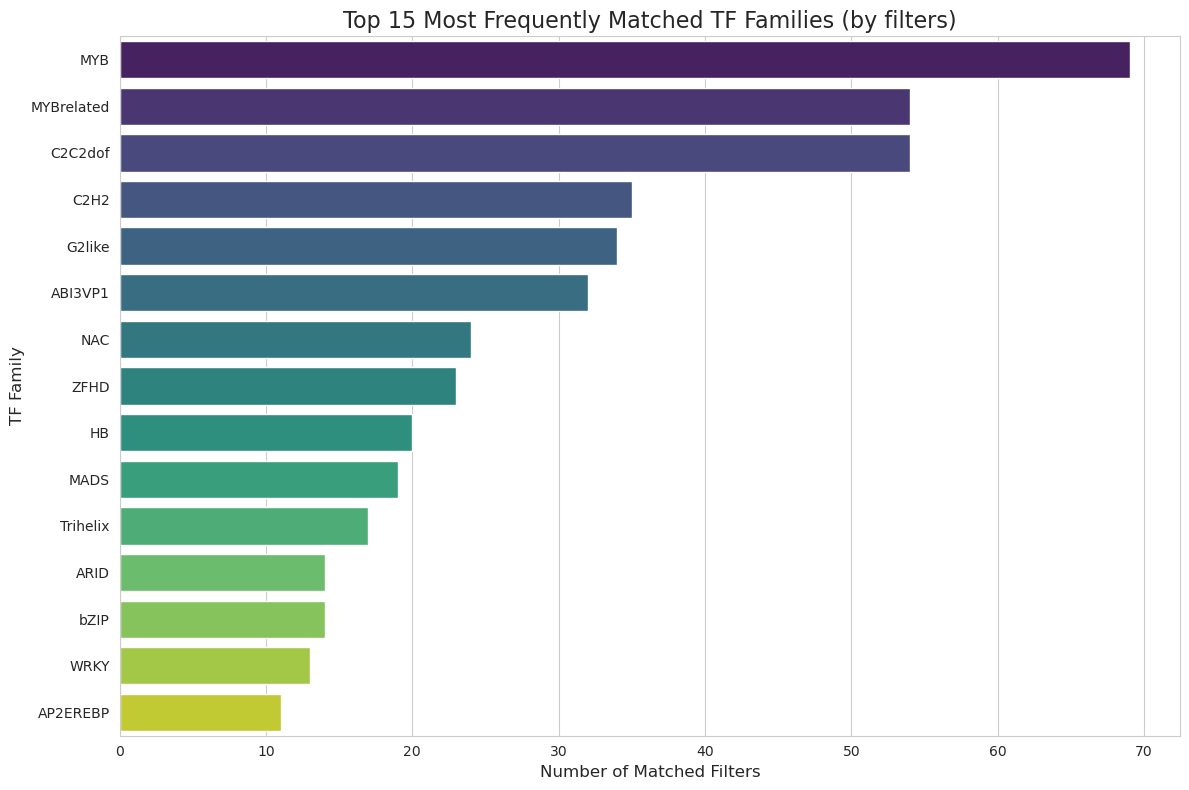

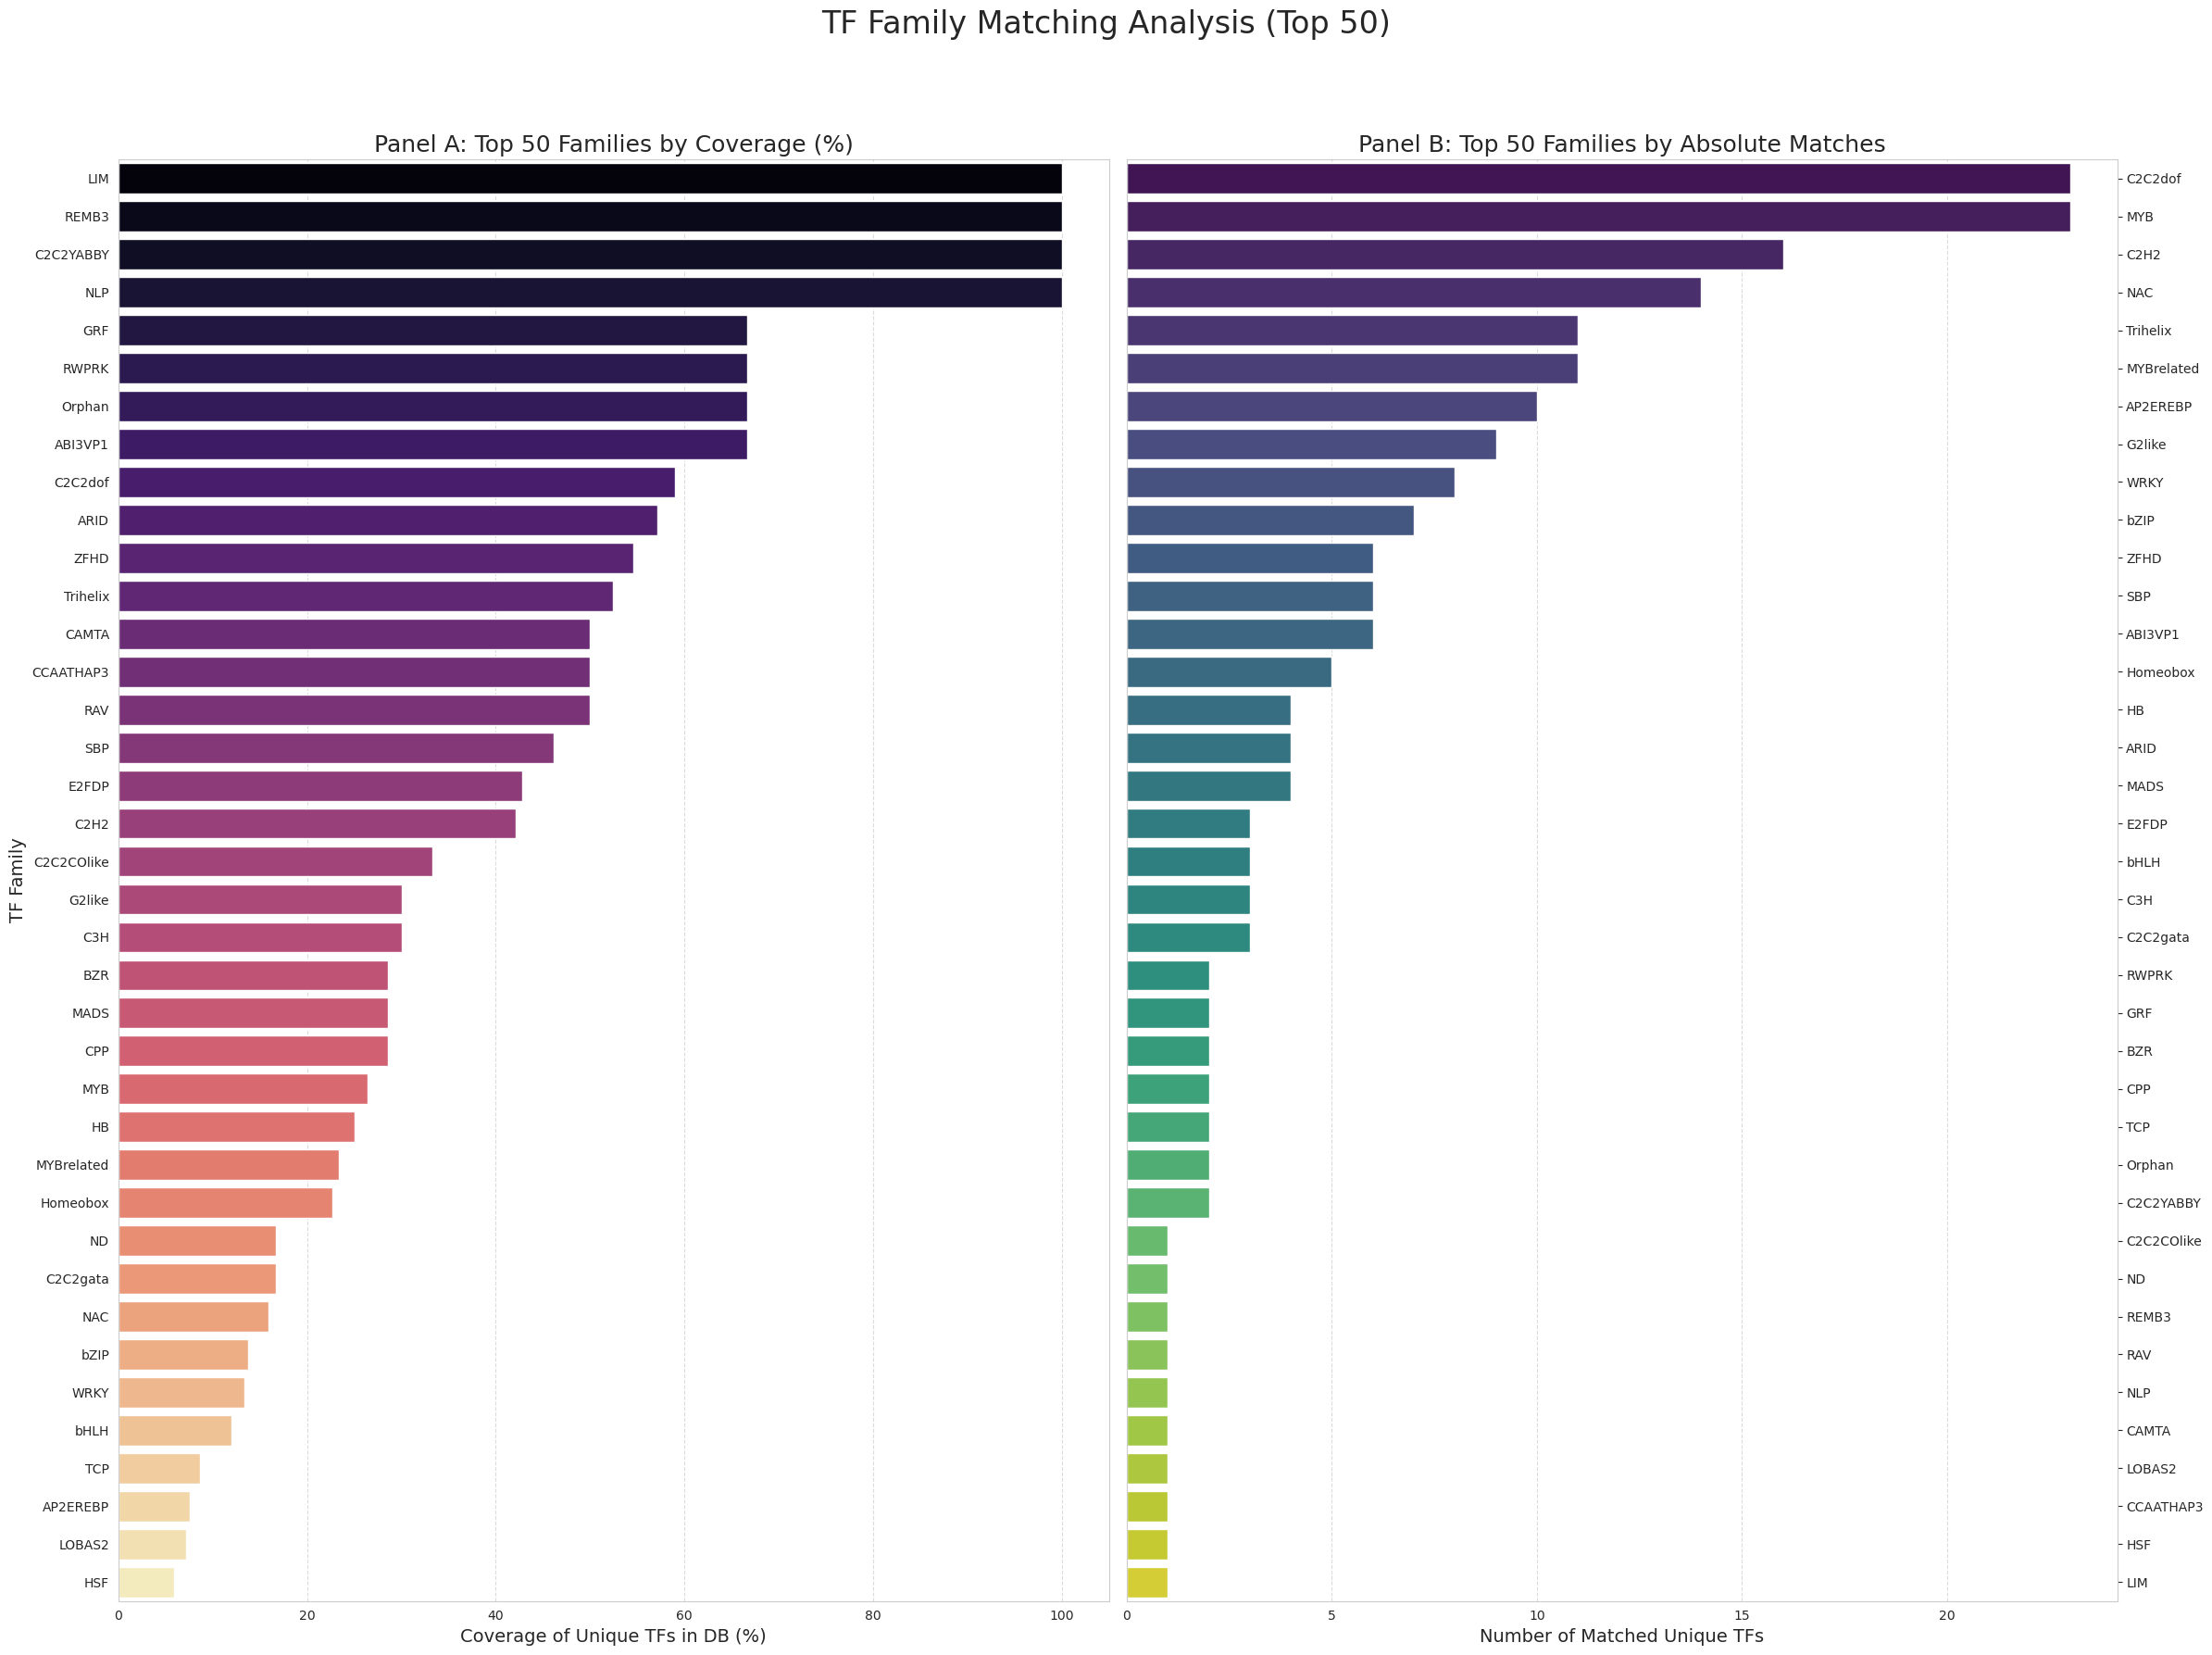

In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to extract TF IDs (e.g., AT2G17410) or fallback identifiers
def extract_tf_id(s):
    if pd.isna(s):
        return s
    s = str(s)
    # Prefer plant gene IDs such as AT2G17410
    m = re.search(r'AT[0-9]+G[0-9]+', s)
    if m:
        return m.group(0)
    # Fallback: text after the first underscore
    if '_' in s:
        return s.split('_', 1)[1]
    # Otherwise return the full string
    return s

if 'summary_df' in locals():

    # ----------------------------
    # 1. Diagnostic output
    # ----------------------------
    print("--- Diagnostics ---")
    print(f"Loaded DataFrame shape (rows, columns): {summary_df.shape}")
    print("First 5 rows of the DataFrame:")
    print(summary_df.head())
    print("--- End diagnostics ---\n")

    # ----------------------------
    # 2. Processing and analysis
    # ----------------------------

    # Ensure no more than 10 columns remain
    num_columns = summary_df.shape[1]
    if num_columns > 10:
        print(f"Detected {num_columns} columns (>10). Only the first 10 columns will be kept.")
        summary_df = summary_df.iloc[:, :10]

    # Rename columns
    summary_df.columns = [
        'Query_ID', 'Target_ID', 'Optimal_offset', 'p-value', 'E-value',
        'q-value', 'Overlap', 'Query_consensus', 'Target_consensus', 'Orientation'
    ]

    # Extract TF family from Target_ID
    summary_df['TF_Family'] = summary_df['Target_ID'].str.split('_').str[0]

    # Extract unique TF identifiers
    summary_df['TF_ID'] = summary_df['Target_ID'].apply(extract_tf_id)

    # Count matched unique TFs per family
    matched_tf_counts = summary_df.groupby('TF_Family')['TF_ID'].nunique()

    # Count matches by filter (original method)
    family_counts = summary_df['TF_Family'].value_counts()

    print("\nTF family distribution (by filters):")
    print(family_counts.head(30))
    print("\nNumber of unique TFs matched per family:")
    print(matched_tf_counts.sort_values(ascending=False).head(30))

    # ----------------------------
    # 3. Plot TF family frequency by filters (single panel)
    # ----------------------------
    plt.figure(figsize=(12, 8))
    top_n_filters = 15
    sns.barplot(
        x=family_counts.head(top_n_filters).values,
        y=family_counts.head(top_n_filters).index,
        palette="viridis"
    )
    plt.title(f'Top {top_n_filters} Most Frequently Matched TF Families (by filters)', fontsize=16)
    plt.xlabel('Number of Matched Filters', fontsize=12)
    plt.ylabel('TF Family', fontsize=12)
    plt.tight_layout()
    plt.savefig("TF_Family_Distribution_Corrected.png")
    print("\nSaved figure: TF_Family_Distribution_Corrected.png")

    # ----------------------------
    # 4. Load TF family TF-counts from MEME DB or infer from data
    # ----------------------------

    meme_db_path = '/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/ArabidopsisDAPv1.meme'
    db_family_tf_map = {}

    # Preferred case: load TF counts from MEME database
    if os.path.exists(meme_db_path):
        with open(meme_db_path, 'r') as mf:
            for line in mf:
                if line.startswith('MOTIF '):
                    parts = line.strip().split()
                    if len(parts) >= 2:
                        motif_id = parts[1]
                        family = motif_id.split('_')[0]
                        # Extract TF ID
                        if '.' in motif_id:
                            tf_id = motif_id.split('.', 1)[1]
                        elif len(parts) >= 3:
                            tf_id = parts[2]
                        else:
                            tf_id = extract_tf_id(motif_id)
                        db_family_tf_map.setdefault(family, set()).add(tf_id)

        db_family_counts = pd.Series({k: len(v) for k, v in db_family_tf_map.items()})
        print(f"\nLoaded MEME database: {len(db_family_counts)} TF families detected.")

    else:
        # Fallback: infer TF counts from observed Target_IDs
        print(f"\nMEME DB not found at {meme_db_path}. Inferring TF family totals from observed data.")
        inferred_tf_ids = summary_df['Target_ID'].apply(extract_tf_id)
        inferred_family_map = {}

        for fam, tf in zip(summary_df['TF_Family'], inferred_tf_ids):
            inferred_family_map.setdefault(fam, set()).add(tf)

        db_family_counts = pd.Series({k: len(v) for k, v in inferred_family_map.items()})
        print(f"Inferred {len(db_family_counts)} TF families from existing results.")

    # Compute coverage = (# matched TFs) / (# total TFs in DB)
    common_families = matched_tf_counts.index.intersection(db_family_counts.index)
    matched = matched_tf_counts.reindex(common_families).astype(float)
    db_totals = db_family_counts.reindex(common_families).astype(float)

    db_totals_safe = db_totals.replace(0, np.nan)
    coverage = (matched / db_totals_safe).dropna()
    coverage = coverage[np.isfinite(coverage)]
    coverage = coverage.sort_values(ascending=False)

    # ----------------------------
    # 5. Two-panel figure (coverage % vs absolute TF counts)
    # ----------------------------
    top_n = 50

    # Left panel: percentage coverage
    data_plot_pct = coverage.head(top_n)

    # Right panel: absolute matched TF counts
    sorted_matched_counts = matched_tf_counts.sort_values(ascending=False)
    data_plot_abs = sorted_matched_counts.head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(24, 18))

    # Panel A — percentage coverage
    sns.barplot(ax=axes[0], x=(data_plot_pct.values * 100), y=data_plot_pct.index, palette="magma")
    axes[0].set_title(f'Panel A: Top {top_n} Families by Coverage (%)', fontsize=18)
    axes[0].set_xlabel('Coverage of Unique TFs in DB (%)', fontsize=14)
    axes[0].set_ylabel('TF Family', fontsize=14)
    axes[0].grid(axis='x', linestyle='--', alpha=0.7)

    # Panel B — absolute matched TF count
    sns.barplot(ax=axes[1], x=data_plot_abs.values, y=data_plot_abs.index, palette="viridis")
    axes[1].set_title(f'Panel B: Top {top_n} Families by Absolute Matches', fontsize=18)
    axes[1].set_xlabel('Number of Matched Unique TFs', fontsize=14)
    axes[1].set_ylabel('')
    axes[1].yaxis.set_label_position("right")
    axes[1].yaxis.tick_right()
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)

    fig.suptitle('TF Family Matching Analysis (Top 50)', fontsize=24, y=1.02)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    out_name = 'TF_Family_2_Panel_Comparison.png'
    plt.savefig(out_name, dpi=300, bbox_inches='tight')
    print(f"\nSaved figure: {out_name}")

else:
    print("Error: 'summary_df' is not loaded in the current environment.")


Detected 12 columns (>10). Keeping only the first 10 columns.

Unique TFs matched per family (for coverage calculation):
TF_Family
C2C2dof       23
MYB           23
C2H2          16
NAC           14
Trihelix      11
MYBrelated    11
AP2EREBP      10
G2like         9
WRKY           8
bZIP           7
ZFHD           6
SBP            6
ABI3VP1        6
Homeobox       5
HB             4
ARID           4
MADS           4
E2FDP          3
bHLH           3
C3H            3
C2C2gata       3
RWPRK          2
GRF            2
BZR            2
CPP            2
TCP            2
Orphan         2
C2C2YABBY      2
C2C2COlike     1
ND             1
Name: TF_ID, dtype: int64
Loaded MEME database. Found 54 TF families.
Annotating 38 bars with absolute counts.


/tmp/ipykernel_1930423/4074819231.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(



Saved figure: TF_Family_Percentage_With_Absolute_Counts_CLEAN.png


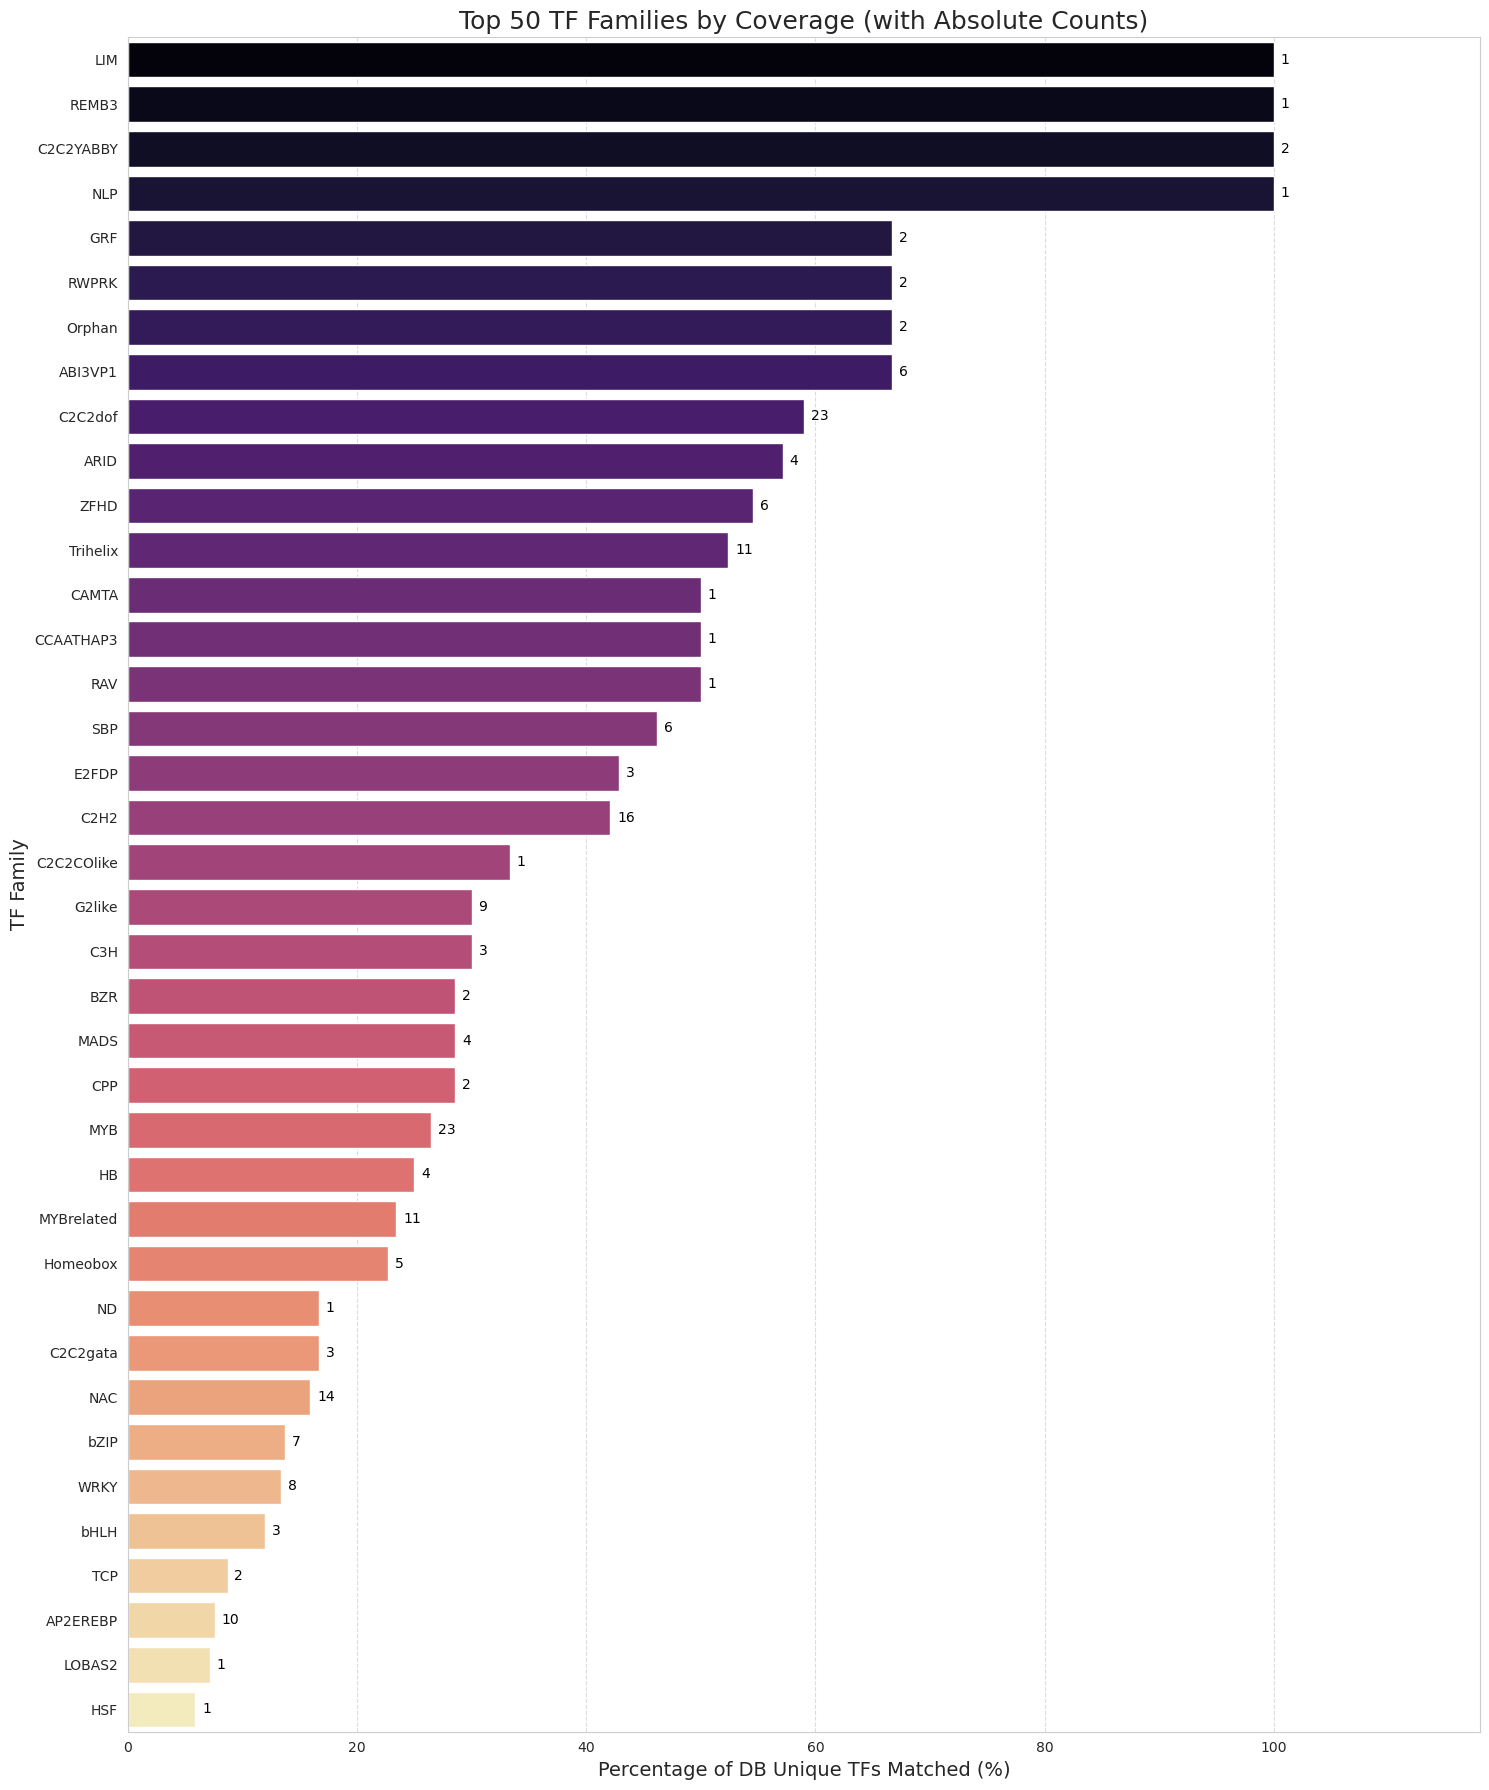

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to extract TF ID
def extract_tf_id(s):
    if pd.isna(s):
        return s
    s = str(s)
    m = re.search(r'AT[0-9]+G[0-9]+', s)
    if m:
        return m.group(0)
    if '_' in s:
        return s.split('_', 1)[1]
    return s

if 'summary_df' in locals():

    # ==========================
    # 1 & 2. Data preparation
    # ==========================
    num_columns = summary_df.shape[1]
    if num_columns > 10:
        print(f"Detected {num_columns} columns (>10). Keeping only the first 10 columns.")
        summary_df = summary_df.iloc[:, :10]

    summary_df.columns = [
        'Query_ID', 'Target_ID', 'Optimal_offset', 'p-value', 'E-value',
        'q-value', 'Overlap', 'Query_consensus', 'Target_consensus', 'Orientation'
    ]
    
    summary_df['TF_Family'] = summary_df['Target_ID'].str.split('_').str[0]
    summary_df['TF_ID'] = summary_df['Target_ID'].apply(extract_tf_id)
    matched_tf_counts = summary_df.groupby('TF_Family')['TF_ID'].nunique()

    print("\nUnique TFs matched per family (for coverage calculation):")
    print(matched_tf_counts.sort_values(ascending=False).head(30))


    # ==========================
    # 3. Load DB and compute coverage
    # ==========================
    meme_db_path = '/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/ArabidopsisDAPv1.meme'
    db_family_tf_map = {}

    if os.path.exists(meme_db_path):
        with open(meme_db_path, 'r') as mf:
            for line in mf:
                if line.startswith('MOTIF '):
                    parts = line.strip().split()
                    if len(parts) >= 2:
                        motif_id = parts[1]
                        family = motif_id.split('_')[0]
                        if '.' in motif_id:
                            tf_id = motif_id.split('.', 1)[1]
                        elif len(parts) >= 3:
                            tf_id = parts[2]
                        else:
                            tf_id = extract_tf_id(motif_id)
                        db_family_tf_map.setdefault(family, set()).add(tf_id)

        db_family_counts = pd.Series({k: len(v) for k, v in db_family_tf_map.items()})
        print(f"Loaded MEME database. Found {len(db_family_counts)} TF families.")

    else:
        print(f"MEME database not found at {meme_db_path}. Inferring TF family counts from results.")
        inferred_tf_ids = summary_df['Target_ID'].apply(extract_tf_id)
        inferred_family_map = {}
        for fam, tf in zip(summary_df['TF_Family'], inferred_tf_ids):
            inferred_family_map.setdefault(fam, set()).add(tf)
        db_family_counts = pd.Series({k: len(v) for k, v in inferred_family_map.items()})
        print(f"Inferred TF family counts from results: {len(db_family_counts)} families.")


    # Compute coverage
    common_families = matched_tf_counts.index.intersection(db_family_counts.index)
    matched = matched_tf_counts.reindex(common_families).astype(float)
    db_totals = db_family_counts.reindex(common_families).astype(float)

    db_totals_safe = db_totals.replace(0, np.nan)
    coverage = (matched / db_totals_safe).dropna()
    coverage = coverage[np.isfinite(coverage)]
    coverage = coverage.sort_values(ascending=False)


    # ==========================
    # 4. Plot (percentage + absolute counts)
    # ==========================
    top_n = 50
    data_plot_pct = coverage.head(top_n)
    abs_counts_for_plot = matched_tf_counts.reindex(data_plot_pct.index).fillna(0)

    plt.figure(figsize=(15, 18))
    
    ax = sns.barplot(
        x=(data_plot_pct.values * 100), 
        y=data_plot_pct.index, 
        palette="magma"
    )

    labels = [f'{int(count):d}' for count in abs_counts_for_plot.values]

    # Bar labeling (1 label per container)
    if len(labels) == len(ax.containers):
        print(f"Annotating {len(ax.containers)} bars with absolute counts.")
        for i, container in enumerate(ax.containers):
            ax.bar_label(container, labels=[labels[i]], padding=5, fontsize=10, color='black')
    else:
        print(f"Warning: number of labels ({len(labels)}) does not match number of bar containers ({len(ax.containers)}). No labels applied.")

    # Formatting
    ax.set_title(f'Top {top_n} TF Families by Coverage (with Absolute Counts)', fontsize=18)
    ax.set_xlabel('Percentage of DB Unique TFs Matched (%)', fontsize=14)
    ax.set_ylabel('TF Family', fontsize=14)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    max_x_val = max(100, (data_plot_pct.values.max() * 100))
    ax.set_xlim(right=max_x_val * 1.18)

    plt.tight_layout()

    out_name = 'TF_Family_Percentage_With_Absolute_Counts_CLEAN.png'
    plt.savefig(out_name, dpi=300, bbox_inches='tight')
    print(f"\nSaved figure: {out_name}")

else:
    print("Error: 'summary_df' is not loaded in the current environment.")


In [5]:
if 'final_summary_df' in locals() and not final_summary_df.empty:
    final_summary_df['p-value'] = pd.to_numeric(final_summary_df['p-value'])
    
    most_significant_matches = final_summary_df.sort_values('p-value').head(10)
    
    print(most_significant_matches[['Target_ID', 'p-value', 'TF_Family']])
    
    top_filters_by_pvalue = most_significant_matches.index.tolist()[:10]
    print(f"{top_filters_by_pvalue}")


                         Target_ID       p-value TF_Family
502          C2H2_tnt.MGP_col_a_m1  4.813880e-08      C2H2
495    AP2EREBP_tnt.ERF73_col_a_m1  6.207580e-08  AP2EREBP
264      HB_tnt.ATHB21_colamp_a_m1  1.298300e-07        HB
214          C2H2_tnt.MGP_col_a_m1  1.451340e-07      C2H2
92      C2C2dof_tnt.dof24_col_a_m1  1.804970e-07   C2C2dof
420  C2C2dof_tnt.dof45_colamp_a_m1  1.985300e-07   C2C2dof
331       C3H_tnt.EMB1789_col_a_m1  2.358660e-07       C3H
9       MYB_tnt.MYB118_colamp_a_m1  2.471160e-07       MYB
30        MYB_tnt.MYB4_col200_a_m1  4.221690e-07       MYB
385         MYB_tnt.MYB98_col_a_m1  7.448080e-07       MYB
[502, 495, 264, 214, 92, 420, 331, 9, 30, 385]



--- Visualizing  top_filters_by_pvalue motifs for filters: [502, 495, 264, 214, 92, 420, 331, 9, 30, 385] ---
--- Processing Filter 502 ---
Successfully created 'Learned Motif' logo matrix for Filter 502.
Successfully parsed matrix for 'Trihelix_tnt.AT3G25990_col_a_m1'.
Match orientation is negative. Applying reverse complement to the database motif.


Motif comparison plot saved as 'Motif_Comparison_Filter_502.png'

--- Processing Filter 495 ---
Successfully created 'Learned Motif' logo matrix for Filter 495.
Successfully parsed matrix for 'C2C2dof_tnt.dof24_colamp_a_m1'.
Motif comparison plot saved as 'Motif_Comparison_Filter_495.png'

--- Processing Filter 264 ---
Successfully created 'Learned Motif' logo matrix for Filter 264.
Successfully parsed matrix for 'RWPRK_tnt.RKD2_col_a_m1'.
Match orientation is negative. Applying reverse complement to the database motif.
Motif comparison plot saved as 'Motif_Comparison_Filter_264.png'

--- Processing Filter 214 ---
Successfully created 'Learned Motif' logo matrix for Filter 214.
--- Processing Filter 92 ---
Successfully created 'Learned Motif' logo matrix for Filter 92.
Successfully parsed matrix for 'C2C2dof_tnt.dof24_col_a_m1'.
Match orientation is negative. Applying reverse complement to the database motif.
Motif comparison plot saved as 'Motif_Comparison_Filter_92.png'

--- Processi

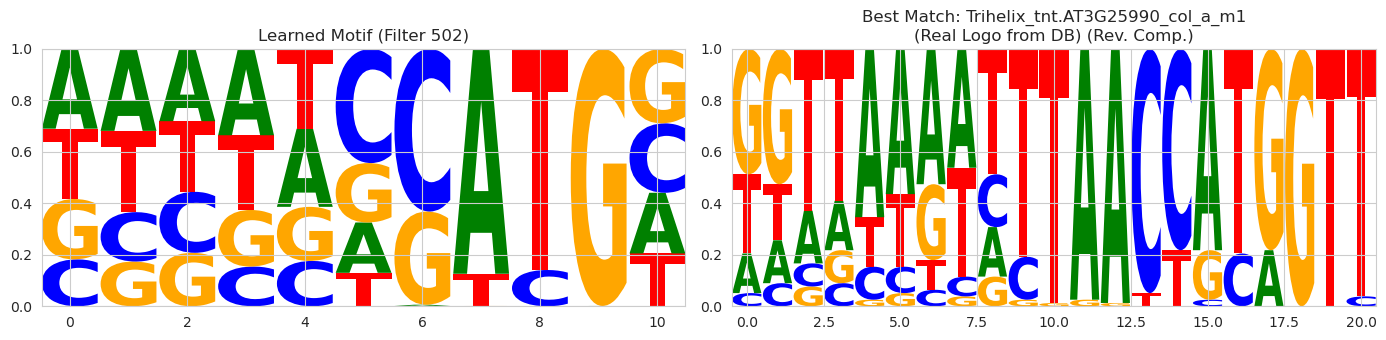

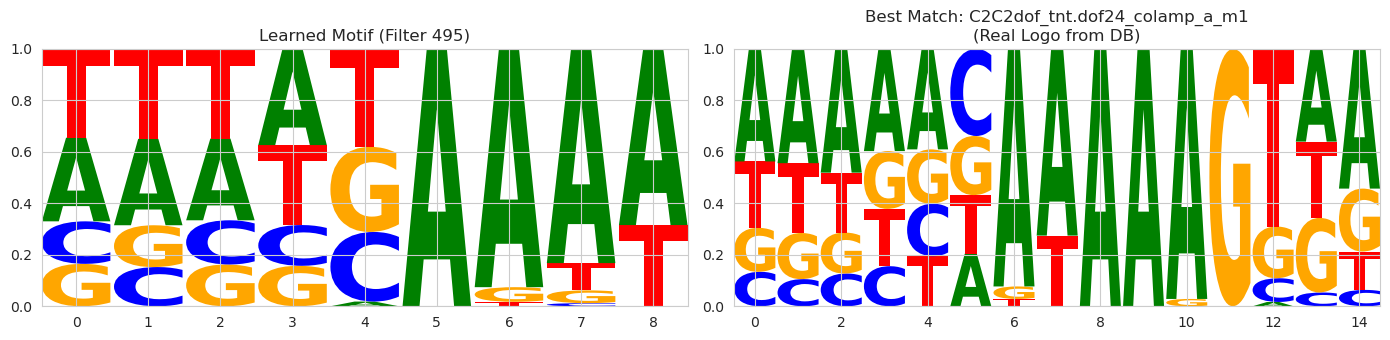

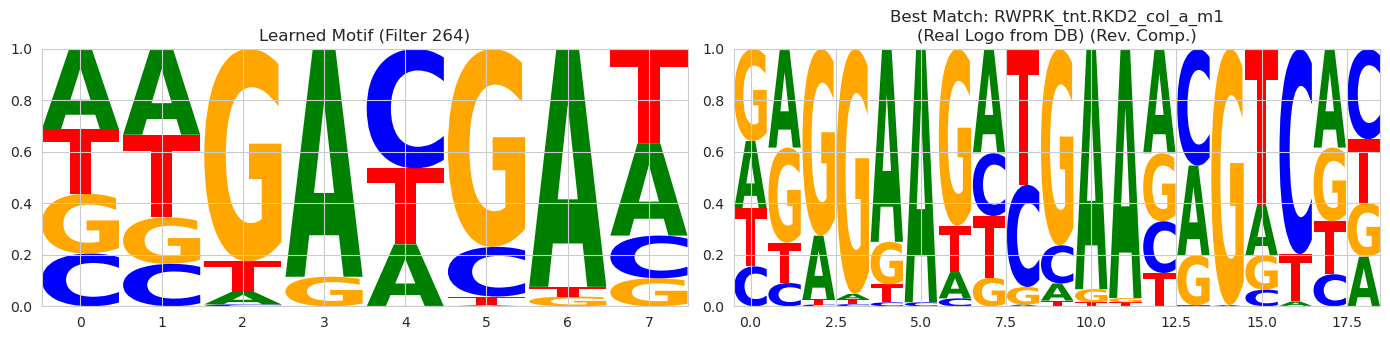

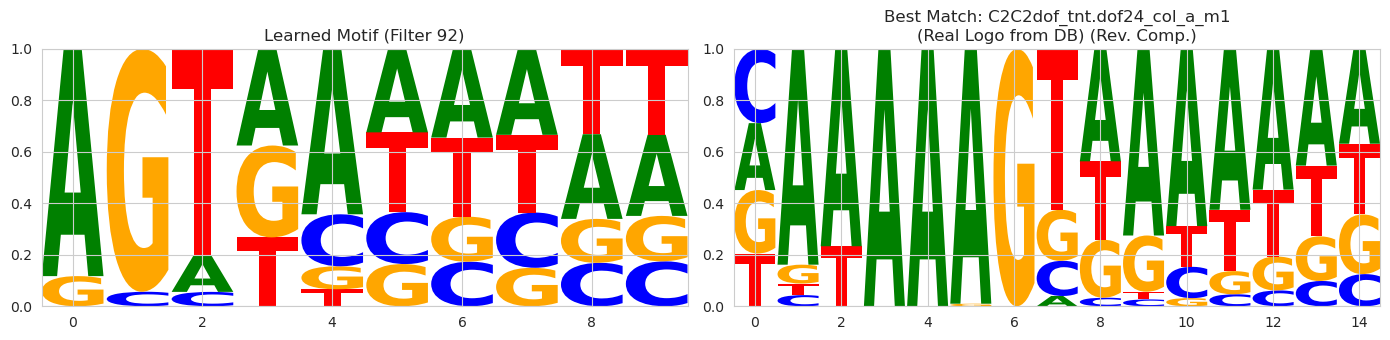

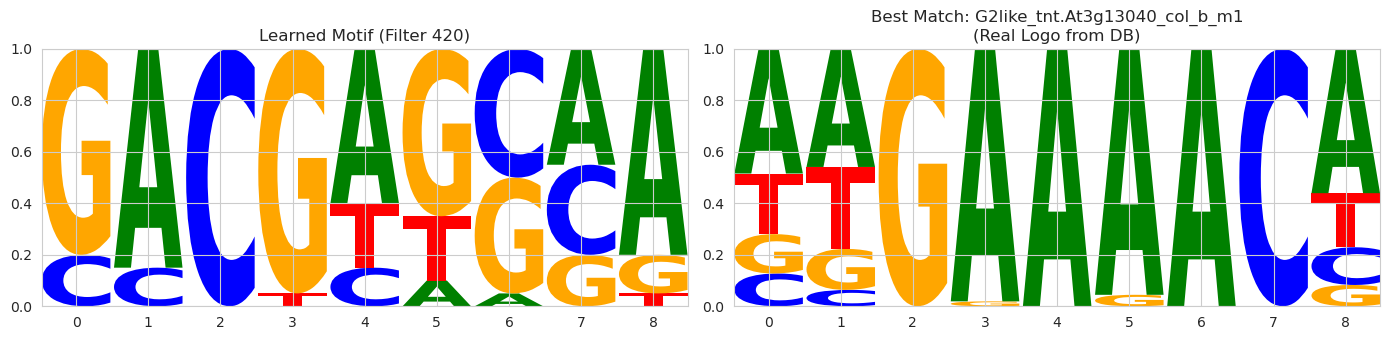

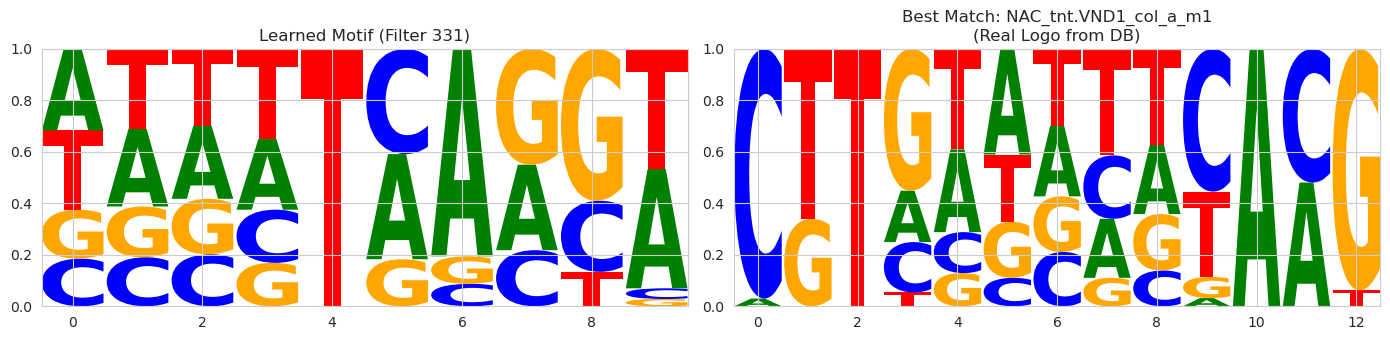

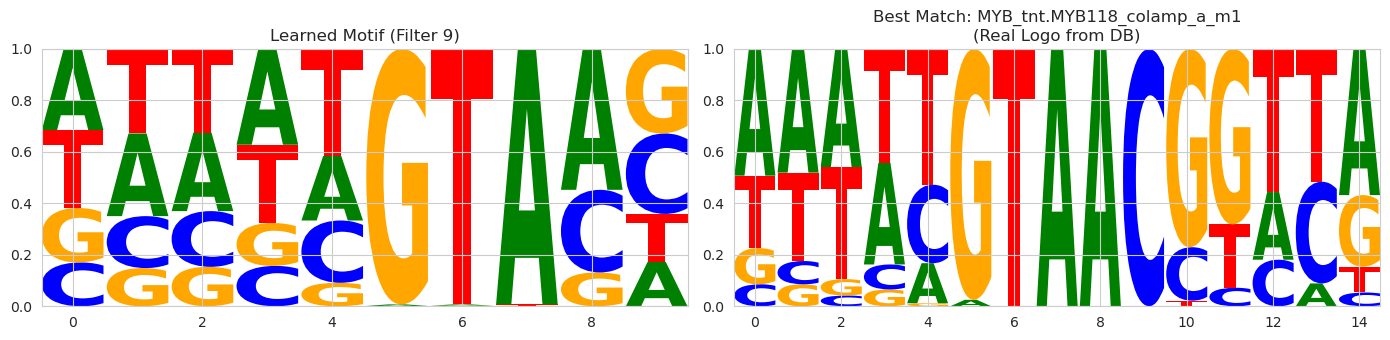

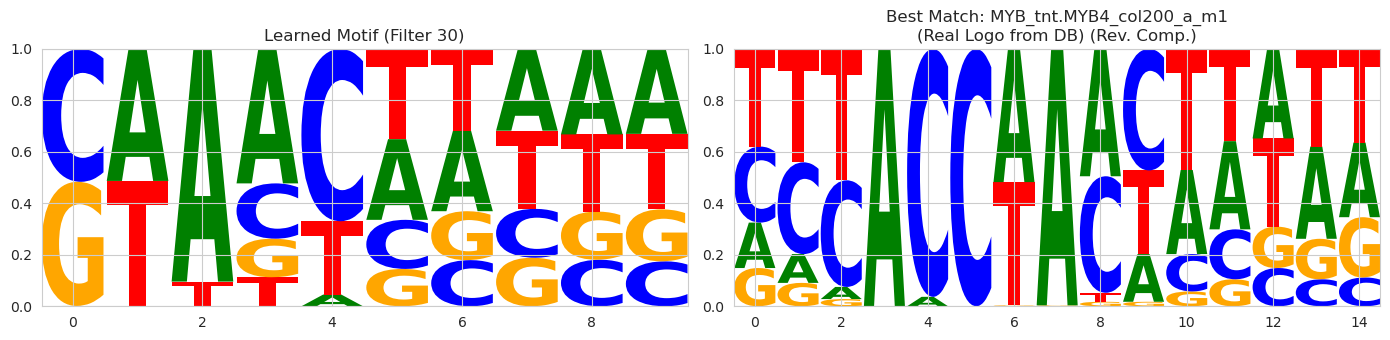

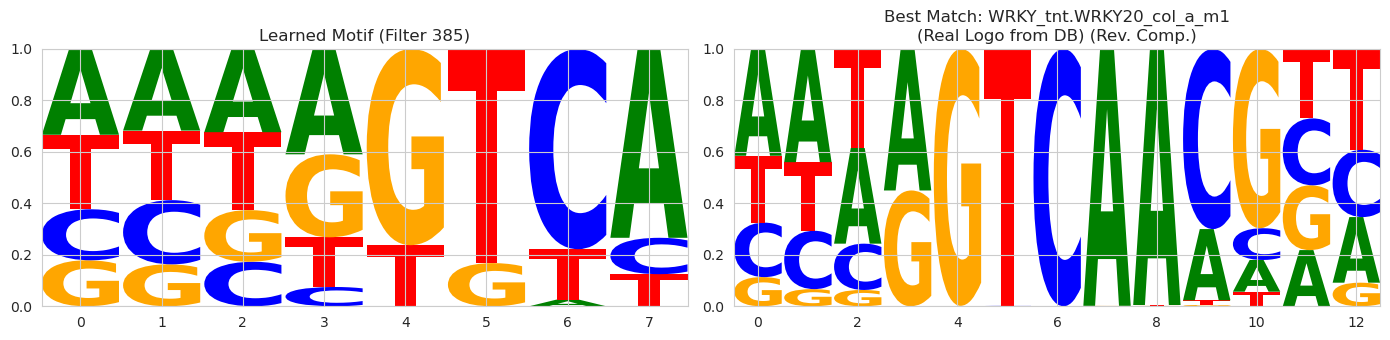

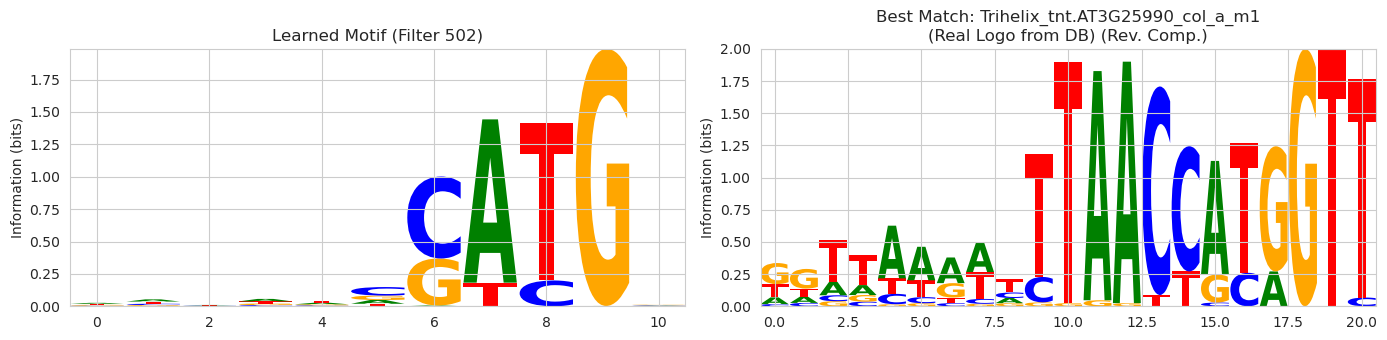

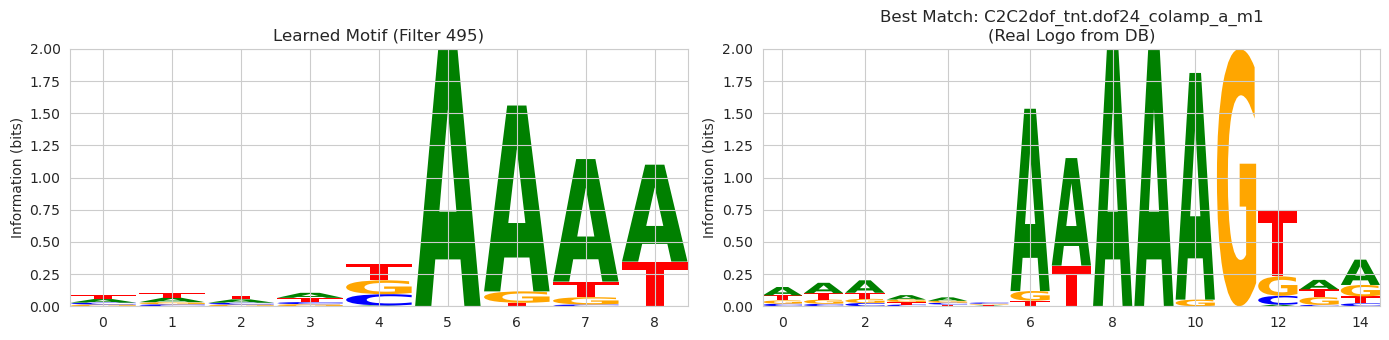

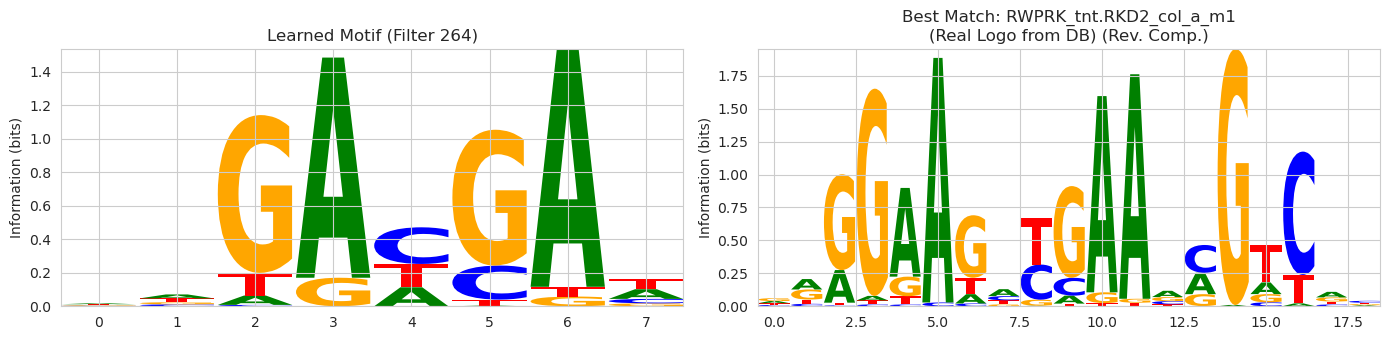

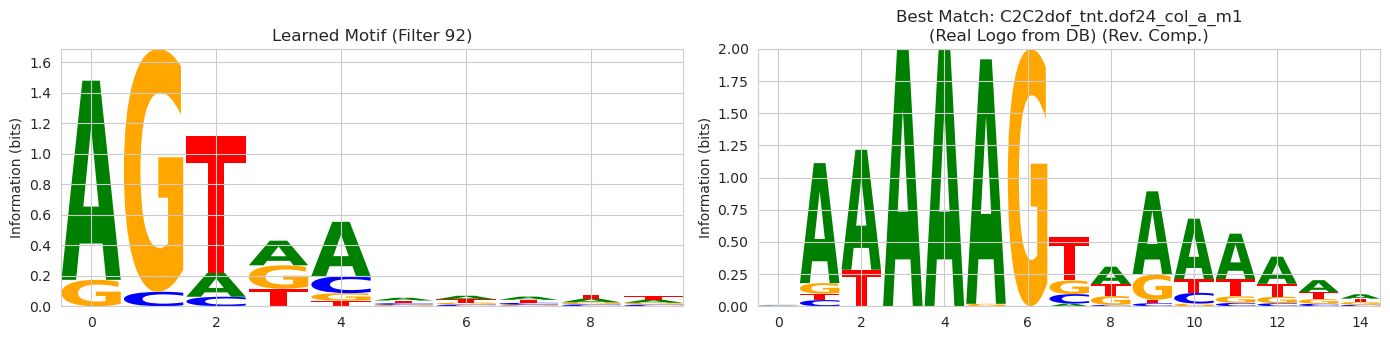

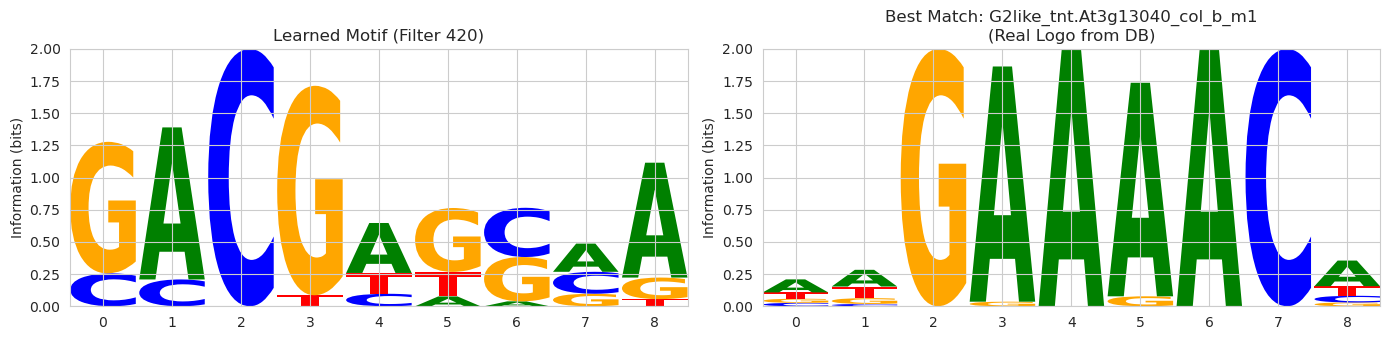

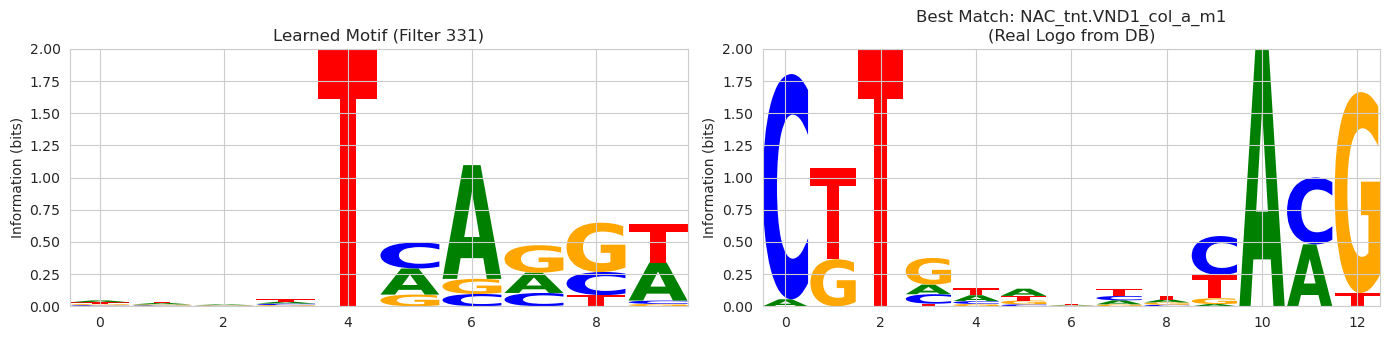

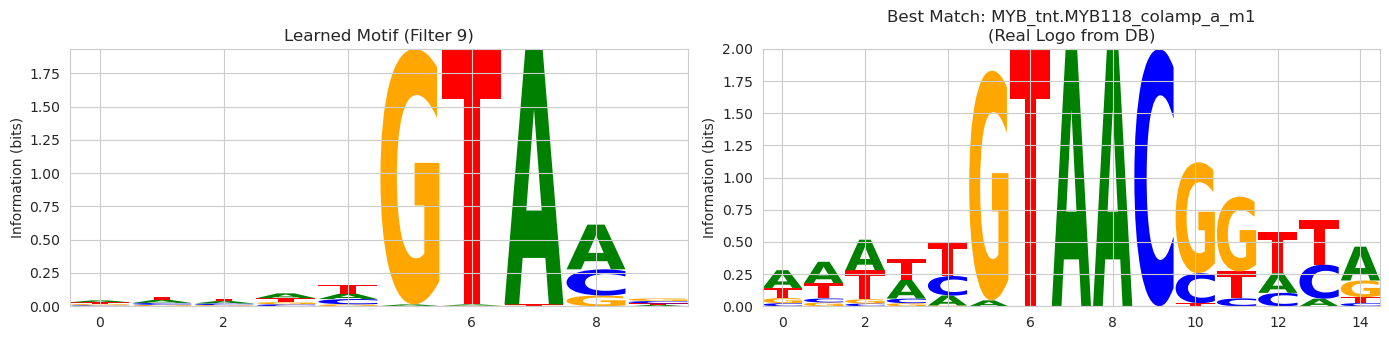

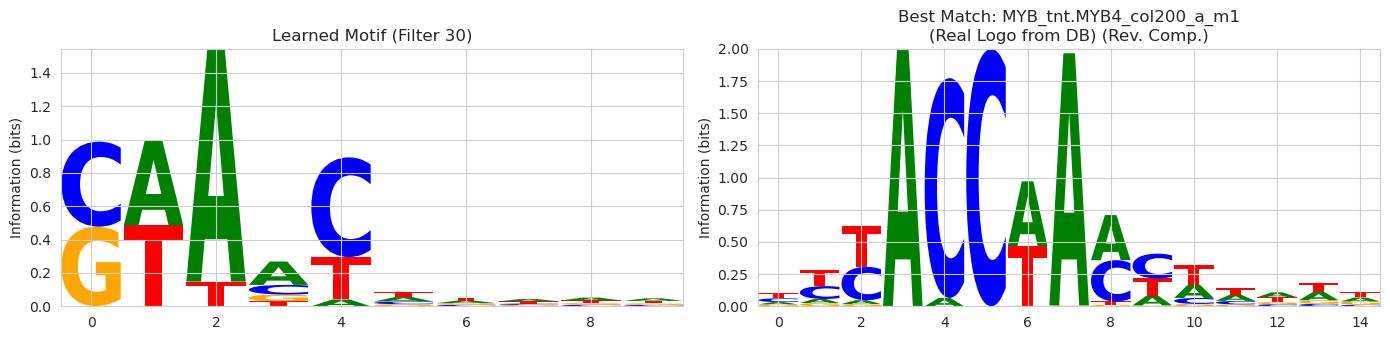

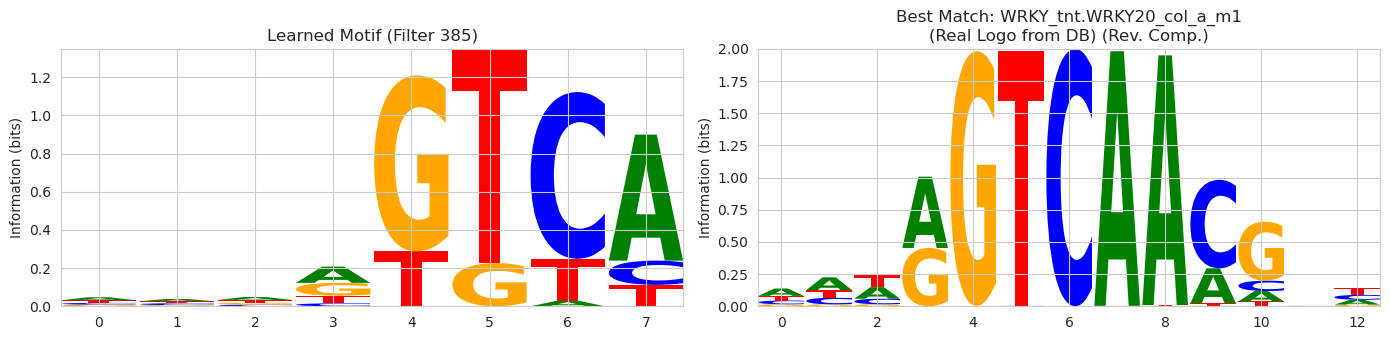

In [6]:

import logomaker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

def parse_meme_file(meme_filepath, motif_id):
    try:
        with open(meme_filepath, 'r') as f:
            lines = f.readlines()
        
        start_index = -1
        search_string = f"MOTIF {motif_id}"
        
        for i, line in enumerate(lines):
            if line.strip().startswith(search_string):
                parts = line.strip().split()
                if len(parts) >= 2 and parts[1] == motif_id:
                    start_index = i
                    break

        if start_index == -1:
            print(f"[Warning] Motif ID '{motif_id}' not found in {meme_filepath}")
            return None

        matrix_header_index = start_index + 1
        while "letter-probability matrix" not in lines[matrix_header_index]:
            matrix_header_index += 1
            if matrix_header_index >= len(lines):
                print(f"[Warning] Could not find matrix header for motif '{motif_id}'.")
                return None
        
        num_rows = int(lines[matrix_header_index].strip().split('w= ')[1].split(' ')[0])
        matrix_lines = lines[matrix_header_index + 1 : matrix_header_index + 1 + num_rows]
        matrix_data = [list(map(float, line.strip().split())) for line in matrix_lines]
        
        if len(matrix_data[0]) != 4:
            print(f"[Warning] Matrix for motif '{motif_id}' does not have 4 columns.")
            return None

        return pd.DataFrame(matrix_data, columns=['A', 'C', 'G', 'T'])

    except Exception as e:
        print(f"[Error] Failed to parse MEME file for motif '{motif_id}': {e}")
        return None

def visualize_motif_comparison(filter_id, streme_base_path, tomtom_base_path, meme_db_path=None):
    print(f"--- Processing Filter {filter_id} ---")
    try:
        streme_sites_path = os.path.join(streme_base_path, f"filter{filter_id}", "sites.tsv")
        streme_df = pd.read_csv(streme_sites_path, sep='\s+', comment='#')

        seq_lengths = streme_df['site_Sequence'].str.len()
        length_counts = Counter(seq_lengths)
        
        if len(length_counts) > 1:
            modal_length = max(length_counts, key=length_counts.get)
            streme_df_filtered = streme_df[seq_lengths == modal_length].copy()
        else:
            streme_df_filtered = streme_df.copy()

        learned_motif_counts = logomaker.alignment_to_matrix(streme_df_filtered['site_Sequence'])
        learned_motif_probs = learned_motif_counts.div(learned_motif_counts.sum(axis=1), axis=0)
        print(f"Successfully created 'Learned Motif' logo matrix for Filter {filter_id}.")

        tomtom_path = os.path.join(tomtom_base_path, f"filter{filter_id}", "tomtom.tsv")
        tomtom_df = pd.read_csv(tomtom_path, sep='\s+', comment='#')
        
        if tomtom_df.empty:
            print(f"Warning: tomtom.tsv for Filter {filter_id} is empty.")
            return

        best_match = tomtom_df.iloc[0]
        best_match_id = best_match['Target_ID']
        orientation = best_match['Orientation'] 
        matched_motif_df = None
        logo_subtitle = "(Logo Unavailable)"
        
        if meme_db_path and os.path.exists(meme_db_path):
            matched_motif_df = parse_meme_file(meme_db_path, best_match_id)
            if matched_motif_df is not None:
                print(f"Successfully parsed matrix for '{best_match_id}'.")
                logo_subtitle = "(Real Logo from DB)"
                if orientation == '-':
                    print(f"Match orientation is negative. Applying reverse complement to the database motif.")
                    rc_df = matched_motif_df.iloc[::-1]
                    rc_df = rc_df[['T', 'G', 'C', 'A']]
                    rc_df = rc_df.reset_index(drop=True)
                    rc_df.columns = ['A', 'C', 'G', 'T']
                    
                    matched_motif_df = rc_df
                    logo_subtitle += " (Rev. Comp.)"

        fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
        
        logomaker.Logo(learned_motif_probs, ax=axes[0], color_scheme='classic')
        axes[0].set_title(f'Learned Motif (Filter {filter_id})')
        
        if matched_motif_df is not None:
            logomaker.Logo(matched_motif_df, ax=axes[1], color_scheme='classic')
        else:
            axes[1].text(0.5, 0.5, 'Matched Motif Data\nNot Found in MEME file', 
                         ha='center', va='center', fontsize=10, color='gray')
            axes[1].set_xticks([]); axes[1].set_yticks([])

        axes[1].set_title(f'Best Match: {best_match_id}\n{logo_subtitle}')
        
        plt.tight_layout()
        save_name = f"Motif_Comparison_Filter_{filter_id}.png"
        plt.savefig(save_name)
        print(f"Motif comparison plot saved as '{save_name}'\n")

    except FileNotFoundError as e:
        print(f"Error: File not found - {e}. Please check your paths.")
    except Exception as e:
        print(f"An error occurred while processing Filter {filter_id}: {e}")
def visualize_motif_comparison_infobit(filter_id, streme_base_path, tomtom_base_path, meme_db_path=None):
    print(f"--- Processing Filter {filter_id} (info bits) ---")
    try:
        # 1. get STREME sites
        streme_sites_path = os.path.join(streme_base_path, f"filter{filter_id}", "sites.tsv")
        streme_df = pd.read_csv(streme_sites_path, sep=r'\s+', comment='#')

        # 2. get modal length 
        seq_lengths = streme_df['site_Sequence'].str.len()
        length_counts = Counter(seq_lengths)
        
        if len(length_counts) > 1:
            modal_length = max(length_counts, key=length_counts.get)
            streme_df_filtered = streme_df[seq_lengths == modal_length].copy()
        else:
            streme_df_filtered = streme_df.copy()

        # 3. alignment -> counts -> probability -> information bits
        learned_counts = logomaker.alignment_to_matrix(
            streme_df_filtered['site_Sequence'],
            to_type='counts'
        )
        learned_probs = learned_counts.div(learned_counts.sum(axis=1), axis=0)

        learned_info = logomaker.transform_matrix(
            learned_probs,
            from_type='probability',
            to_type='information'
        )

        print(f"Successfully created 'Learned Motif' info-bit logo matrix for Filter {filter_id}.")

        # 4. get tomtom result
        tomtom_path = os.path.join(tomtom_base_path, f"filter{filter_id}", "tomtom.tsv")
        tomtom_df = pd.read_csv(tomtom_path, sep=r'\s+', comment='#')
        
        if tomtom_df.empty:
            print(f"Warning: tomtom.tsv for Filter {filter_id} is empty.")
            return

        best_match = tomtom_df.iloc[0]
        best_match_id = best_match['Target_ID']
        orientation = best_match['Orientation']   # '+' or '-'
        matched_motif_info = None
        logo_subtitle = "(Logo Unavailable)"

        if meme_db_path and os.path.exists(meme_db_path):
            matched_motif_df = parse_meme_file(meme_db_path, best_match_id)
            if matched_motif_df is not None:
                print(f"Successfully parsed probability matrix for '{best_match_id}'.")
                logo_subtitle = "(Real Logo from DB)"

                if orientation == '-':
                    print(f"Match orientation is negative. Applying reverse complement to the database motif.")
                    rc_df = matched_motif_df.iloc[::-1]
                    rc_df = rc_df[['T', 'G', 'C', 'A']]
                    rc_df = rc_df.reset_index(drop=True)
                    rc_df.columns = ['A', 'C', 'G', 'T']
                    matched_motif_df = rc_df
                    logo_subtitle += " (Rev. Comp.)"

                matched_motif_info = logomaker.transform_matrix(
                    matched_motif_df,
                    from_type='probability',
                    to_type='information'
                )

        fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
        
        # Learned motif in bits
        logomaker.Logo(learned_info, ax=axes[0], color_scheme='classic')
        axes[0].set_title(f'Learned Motif (Filter {filter_id})')
        axes[0].set_ylabel('Information (bits)')

        # DB motif in bits
        if matched_motif_info is not None:
            logomaker.Logo(matched_motif_info, ax=axes[1], color_scheme='classic')
            axes[1].set_ylabel('Information (bits)')
        else:
            axes[1].text(
                0.5, 0.5,
                'Matched Motif Data\nNot Found in MEME file',
                ha='center', va='center',
                fontsize=10, color='gray'
            )
            axes[1].set_xticks([]); axes[1].set_yticks([])

        axes[1].set_title(f'Best Match: {best_match_id}\n{logo_subtitle}')
        
        plt.tight_layout()
        save_name = f"Motif_Comparison_Filter_{filter_id}_info_bits.png"
        plt.savefig(f"/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/Motif_comparison/{save_name}", dpi=300)
        plt.close(fig)
        print(f"Motif comparison (info bits) plot saved as '{save_name}'\n")

    except FileNotFoundError as e:
        print(f"Error: File not found - {e}. Please check your paths.")
    except Exception as e:
        print(f"An error occurred while processing Filter {filter_id} (info bits): {e}")
streme_results_base_path = "/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/stremeresult"
tomtom_results_base_path = "/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/tomtomresult"
meme_database_path = "/s/chromatin/m/nobackup/ahmed/DeepPlant/haoxuan/ArabidopsisDAPv1.meme"

filters_to_show = top_filters_by_pvalue
print(f"\n--- Visualizing  top_filters_by_pvalue motifs for filters: {filters_to_show} ---")
for filter_num in filters_to_show:
    visualize_motif_comparison(
        filter_id=filter_num,
        streme_base_path=streme_results_base_path,
        tomtom_base_path=tomtom_results_base_path,
        meme_db_path=meme_database_path
    )
print(f"\n--- Visualizing top_filters_by_pvalue motifs for filters info version: {filters_to_show} ---")
for filter_num in filters_to_show:
    visualize_motif_comparison_infobit(
        filter_id=filter_num,
        streme_base_path=streme_results_base_path,
        tomtom_base_path=tomtom_results_base_path,
        meme_db_path=meme_database_path
    )

In [7]:
if 'family_counts' in locals() and 'final_summary_df' in locals():
    # get top family with most TF
    top_3_families = family_counts.head(3).index.tolist()
    
    filters_from_top_families = []
    
    for family in top_3_families:
        family_df = final_summary_df[final_summary_df['TF_Family'] == family]
        best_in_family = family_df.sort_values('q-value').iloc[0]
        filters_from_top_families.append(best_in_family.name)
        
    print(f"{filters_from_top_families}")

[9, 160, 92]



--- Visualizing top_filters_from_top_families motifs for filters: [9, 160, 92] ---
--- Processing Filter 9 ---
Successfully created 'Learned Motif' logo matrix for Filter 9.
Successfully parsed matrix for 'MYB_tnt.MYB118_colamp_a_m1'.
Motif comparison plot saved as 'Motif_Comparison_Filter_9.png'

--- Processing Filter 160 ---
Successfully created 'Learned Motif' logo matrix for Filter 160.
Successfully parsed matrix for 'RAV_tnt.RAV1_col_m1'.
Match orientation is negative. Applying reverse complement to the database motif.
Motif comparison plot saved as 'Motif_Comparison_Filter_160.png'

--- Processing Filter 92 ---
Successfully created 'Learned Motif' logo matrix for Filter 92.
Successfully parsed matrix for 'C2C2dof_tnt.dof24_col_a_m1'.
Match orientation is negative. Applying reverse complement to the database motif.
Motif comparison plot saved as 'Motif_Comparison_Filter_92.png'


--- Visualizing top_filters_from_top_families motifs for filters info version: [9, 160, 92] ---
--- P

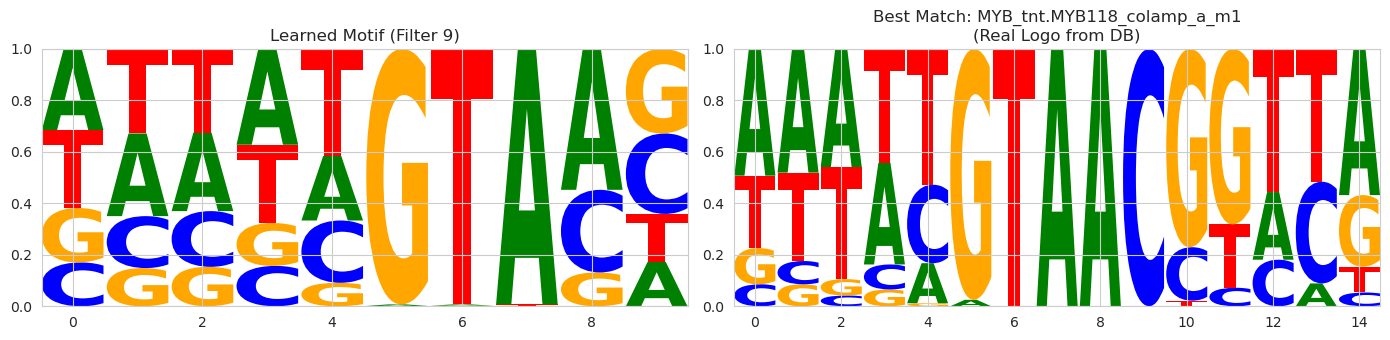

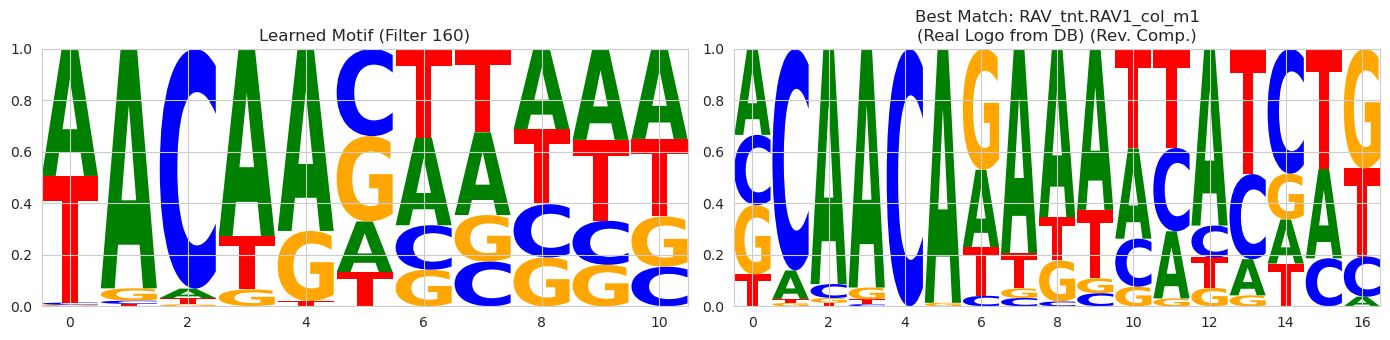

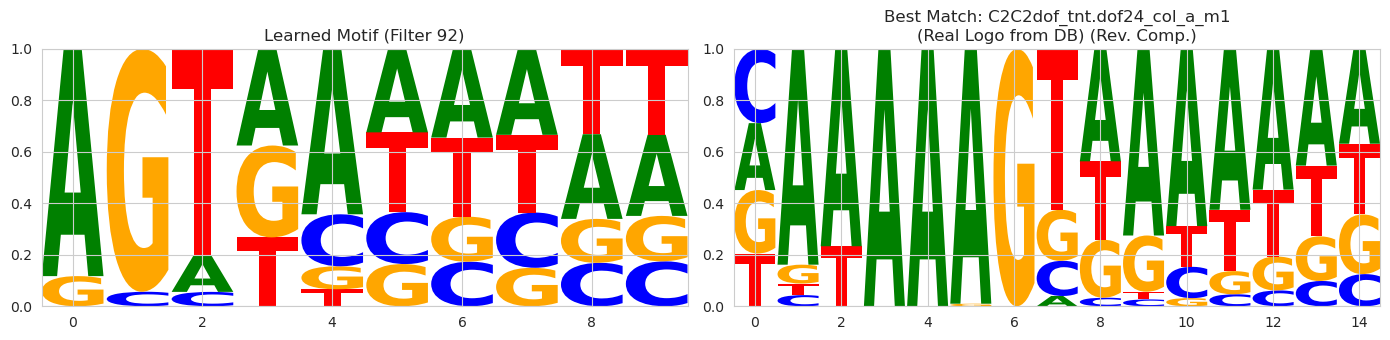

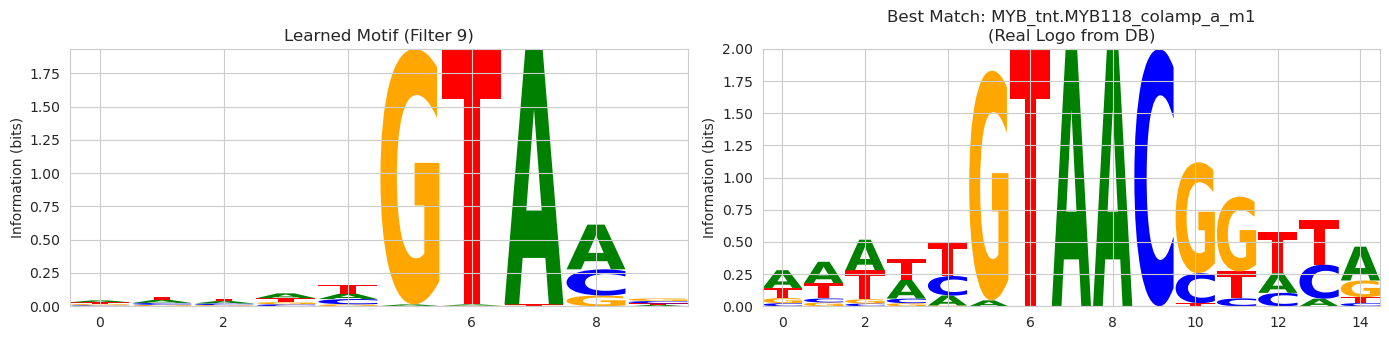

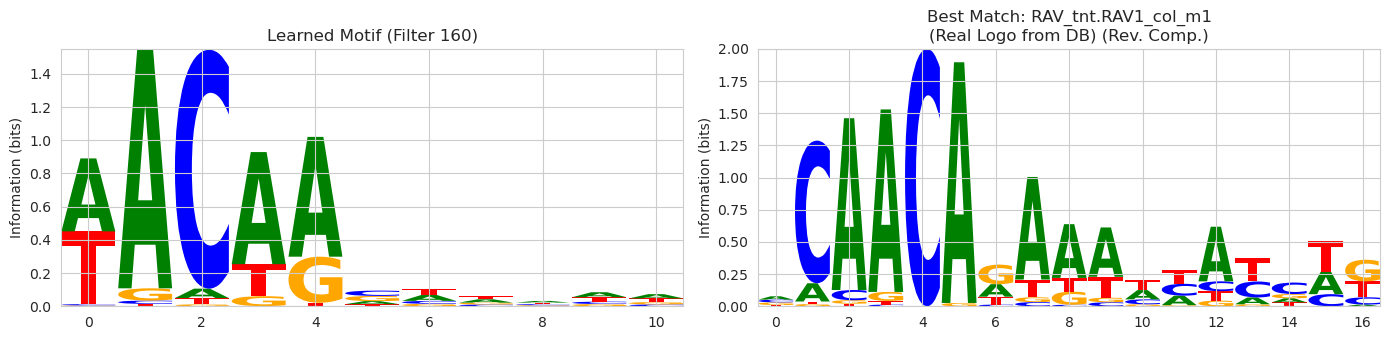

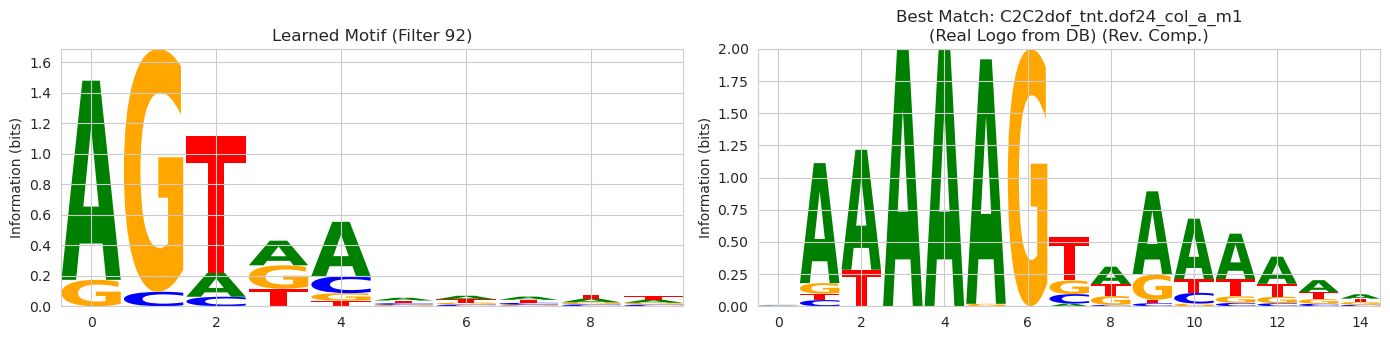

In [8]:
filters_to_show = filters_from_top_families
print(f"\n--- Visualizing top_filters_from_top_families motifs for filters: {filters_to_show} ---")
for filter_num in filters_to_show:
    visualize_motif_comparison(
        filter_id=filter_num,
        streme_base_path=streme_results_base_path,
        tomtom_base_path=tomtom_results_base_path,
        meme_db_path=meme_database_path
    )
print(f"\n--- Visualizing top_filters_from_top_families motifs for filters info version: {filters_to_show} ---")
for filter_num in filters_to_show:
    visualize_motif_comparison_infobit(
        filter_id=filter_num,
        streme_base_path=streme_results_base_path,
        tomtom_base_path=tomtom_results_base_path,
        meme_db_path=meme_database_path
    )

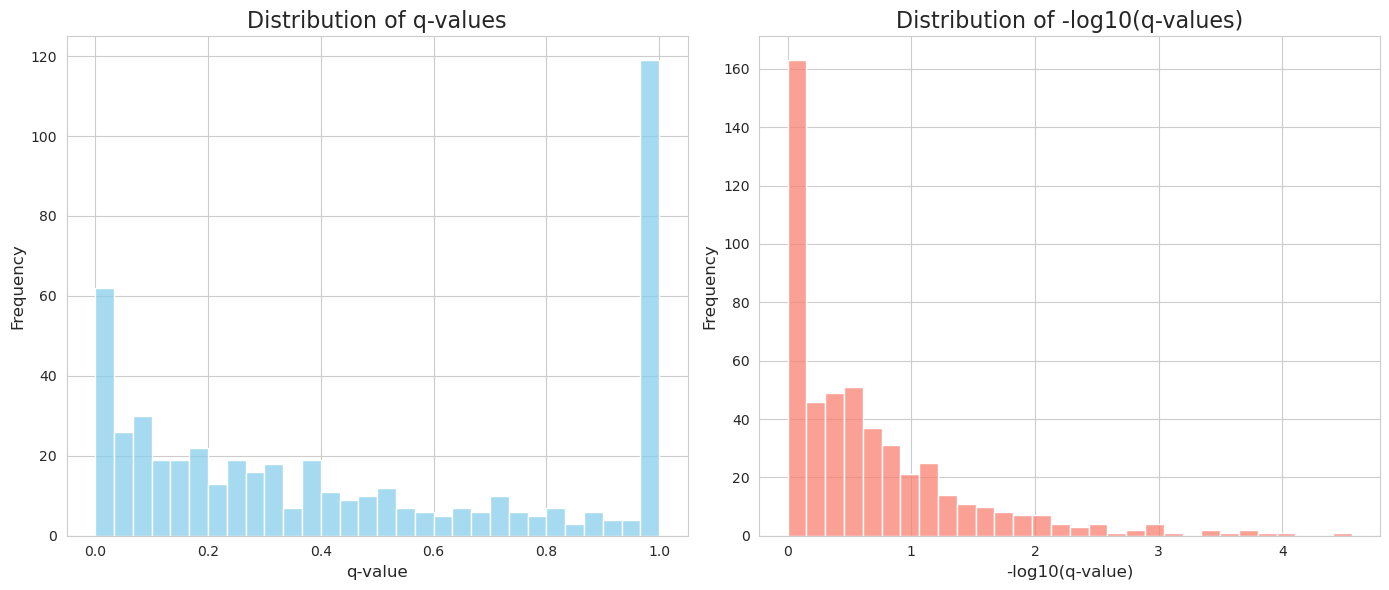

In [9]:
if 'summary_df' in locals():
    summary_df['q-value'] = pd.to_numeric(summary_df['q-value'], errors='coerce')
    summary_df.dropna(subset=['q-value'], inplace=True)
    
    summary_df['q-value_log'] = -np.log10(summary_df['q-value'].replace(0, 1e-300))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.histplot(data=summary_df, x='q-value', bins=30, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of q-values', fontsize=16)
    axes[0].set_xlabel('q-value', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)

    sns.histplot(data=summary_df, x='q-value_log', bins=30, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of -log10(q-values)', fontsize=16)
    axes[1].set_xlabel('-log10(q-value)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    
    plt.tight_layout()

In [10]:
if 'summary_df' in locals():
    summary_df['p-value'] = pd.to_numeric(summary_df['p-value'], errors='coerce')
    summary_df.dropna(subset=['q-value'], inplace=True)
    
    summary_df['p-value_log'] = -np.log10(summary_df['p-value'].replace(0, 1e-300))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.histplot(data=summary_df, x='p-value', bins=30, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of p-values', fontsize=16)
    axes[0].set_xlabel('p-value', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)

    sns.histplot(data=summary_df, x='p-value_log', bins=30, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of -log10(p-values)', fontsize=16)
    axes[1].set_xlabel('-log10(p-value)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    
    #plt.tight_layout()
plt.savefig("/s/chromatin/m/nobackup/ahmed/DeepPlant/paper/pvalue.pdf",bbox_inches='tight', pad_inches=0.1,format = 'pdf')
plt.close()